## **0- Set Up**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/RL

/content/drive/MyDrive/RL


In [ ]:
import os
from os import listdir
from os.path import isfile, join
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
from collections import defaultdict

from pathlib import Path
import copy


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/RL/")
DATA_DIR.mkdir(exist_ok=True)
print(DATA_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
root = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti/"

/content/drive/MyDrive/RL


## **1- File Structures**

### Sizes

In [ ]:
root = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti/"
patient = sorted(os.listdir(root))[1]

print(patient)
pdir = os.path.join(root, patient)

for f in sorted(os.listdir(pdir)):
    if f.endswith(".nii.gz"):
        path = os.path.join(pdir, f)
        nii = nib.load(path)
        data = nii.get_fdata()
        print(f"{f:40s} shape={data.shape} spacing={nii.header.get_zooms()}")


patient0001
patient0001_2CH_ED.nii.gz                shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_2CH_ED_gt.nii.gz             shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_2CH_ES.nii.gz                shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_2CH_ES_gt.nii.gz             shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_2CH_half_sequence.nii.gz     shape=(549, 389, 18) spacing=(np.float32(0.308), np.float32(0.308), np.float32(1.0))
patient0001_2CH_half_sequence_gt.nii.gz  shape=(549, 389, 18) spacing=(np.float32(0.308), np.float32(0.308), np.float32(1.0))
patient0001_4CH_ED.nii.gz                shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_4CH_ED_gt.nii.gz             shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
patient0001_4CH_ES.nii.gz                shape=(549, 389) spacing=(np.float32(0.308), np.float32(0.308))
p

In [ ]:
def load_nii(path):
    return nib.load(path).get_fdata()


### ED / ES

In [ ]:
def plot_ED_ES(patient_dir, patient_id):
    views = ["2CH", "4CH"]
    phases = ["ED", "ES"]

    fig, axes = plt.subplots(4, 2, figsize=(10, 18))

    row = 0
    for view in views:
        for phase in phases:
            img = load_nii(os.path.join(
                patient_dir, f"{patient_id}_{view}_{phase}.nii.gz"
            ))
            gt = load_nii(os.path.join(
                patient_dir, f"{patient_id}_{view}_{phase}_gt.nii.gz"
            ))

            axes[row, 0].imshow(img, cmap="gray")
            axes[row, 0].set_title(f"{view} {phase}")
            axes[row, 0].axis("off")

            axes[row, 1].imshow(img, cmap="gray")
            axes[row, 1].imshow(gt, alpha=0.5, cmap="jet")
            axes[row, 1].set_title(f"{view} {phase} + GT")
            axes[row, 1].axis("off")

            row += 1

    plt.tight_layout()
    plt.show()


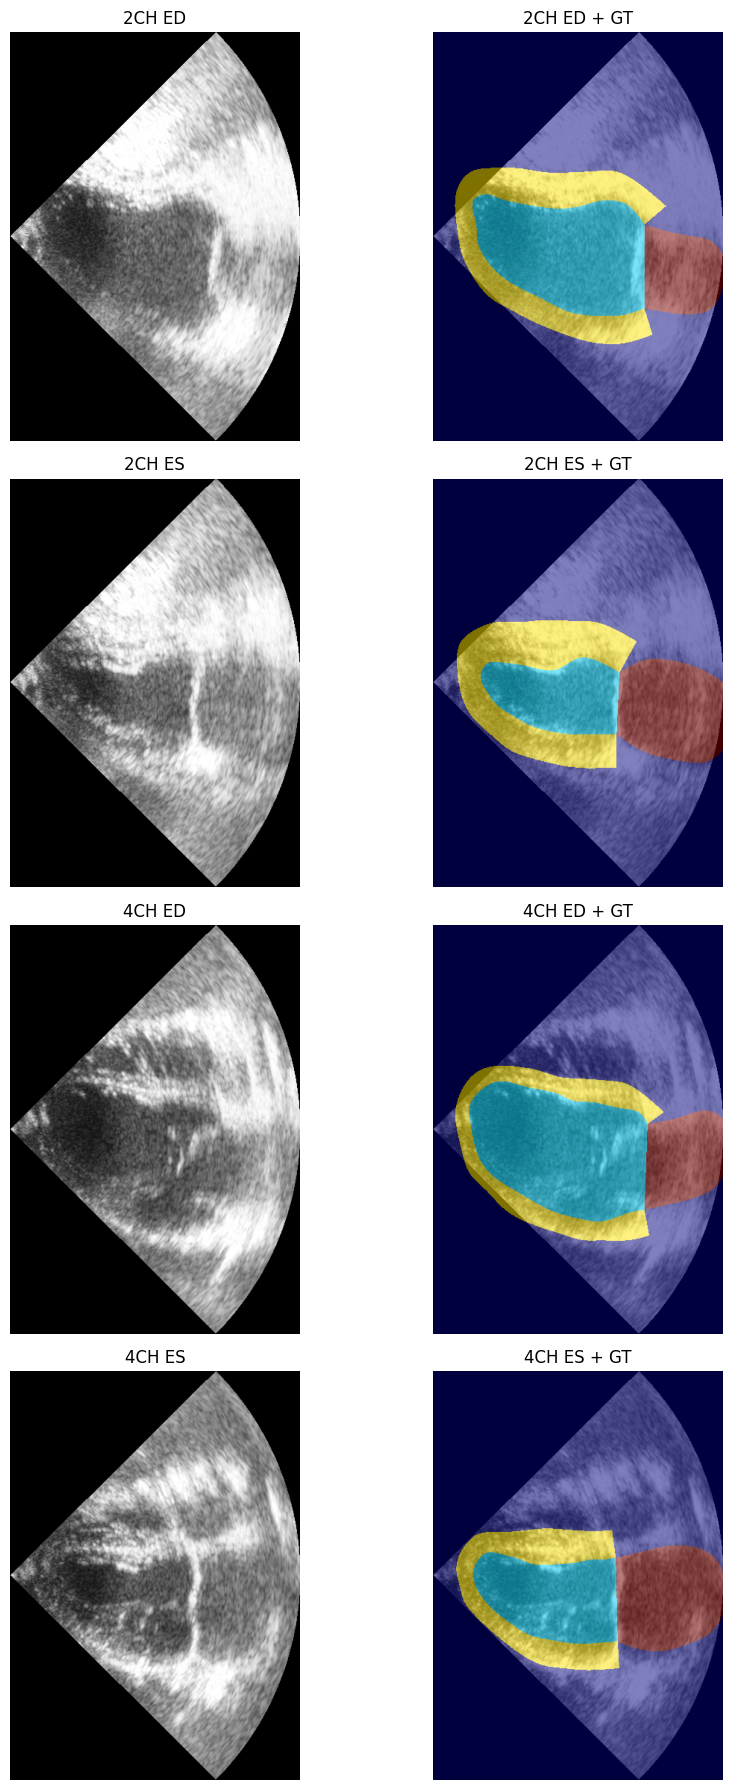

In [ ]:
root = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti"
patient = sorted(os.listdir(root))[1]
pdir = os.path.join(root, patient)

plot_ED_ES(pdir, patient)

## **2- Segmentation**

### Dataset

In [ ]:
class CAMUSSingleFrameDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.samples = []

        patients = sorted([p for p in os.listdir(root_dir) if p.startswith("patient")])

        for p in patients:
            for view in ["2CH", "4CH"]:
                for phase in ["ED", "ES"]:
                    self.samples.append((p, view, phase))

    def __len__(self):
        return len(self.samples)

    def load_nii(self, path):
        return nib.load(path).get_fdata()

    def __getitem__(self, idx):
        pid, view, phase = self.samples[idx]
        pdir = os.path.join(self.root_dir, pid)

        img = self.load_nii(os.path.join(
            pdir, f"{pid}_{view}_{phase}.nii.gz"
        ))
        mask = self.load_nii(os.path.join(
            pdir, f"{pid}_{view}_{phase}_gt.nii.gz"
        ))

        # Normalize
        img = (img - img.mean()) / (img.std() + 1e-8)

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1,H,W)
        mask = torch.tensor(mask, dtype=torch.long)               # (H,W)

        return img, mask


In [ ]:
def split_patients(root_dir):
    patients = sorted([p for p in os.listdir(root_dir) if p.startswith("patient")])
    train = patients[:400]
    val   = patients[400:450]
    test  = patients[450:]
    return train, val, test


In [ ]:
class SubsetCAMUS(Dataset):
    def __init__(self, root_dir, patient_list, img_size=256):
        self.root_dir = root_dir
        self.img_size = img_size
        self.samples = []

        for p in patient_list:
            for view in ["2CH", "4CH"]:
                for phase in ["ED", "ES"]:
                    self.samples.append((p, view, phase))

    def __len__(self):
        return len(self.samples)

    def load_nii(self, path):
        return nib.load(path).get_fdata()

    def __getitem__(self, idx):
        pid, view, phase = self.samples[idx]
        pdir = os.path.join(self.root_dir, pid)

        img = self.load_nii(os.path.join(
            pdir, f"{pid}_{view}_{phase}.nii.gz"
        ))
        mask = self.load_nii(os.path.join(
            pdir, f"{pid}_{view}_{phase}_gt.nii.gz"
        ))

        # Normalize
        img = (img - img.mean()) / (img.std() + 1e-8)

        img = torch.from_numpy(np.ascontiguousarray(img)).float().unsqueeze(0)
        mask = torch.from_numpy(np.ascontiguousarray(mask)).long().unsqueeze(0)

        # resize
        img = TF.resize(img, (self.img_size, self.img_size),
                         interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (self.img_size, self.img_size),
                          interpolation=TF.InterpolationMode.NEAREST)

        return img, mask.squeeze(0)


In [ ]:
root = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti"

train_ids, val_ids, test_ids = split_patients(root)

np.random.seed(42)
train_ids = np.random.choice(train_ids, size=len(train_ids)//2, replace=False)
train_ids = sorted(train_ids)

train_ds = SubsetCAMUS(root, train_ids, img_size=192)
val_ds   = SubsetCAMUS(root, val_ids, img_size=192)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print(x.shape, y.shape)



torch.Size([16, 1, 192, 192]) torch.Size([16, 192, 192])


In [ ]:
test_ds = SubsetCAMUS(root, test_ids, img_size=192)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


### Train

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base=32):
        super().__init__()

        self.d1 = DoubleConv(in_channels, base)
        self.d2 = DoubleConv(base, base*2)
        self.d3 = DoubleConv(base*2, base*4)

        self.u1 = DoubleConv(base*4 + base*2, base*2)
        self.u2 = DoubleConv(base*2 + base, base)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.out = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2))

        x = self.up(c3)
        x = self.u1(torch.cat([x, c2], dim=1))

        x = self.up(x)
        x = self.u2(torch.cat([x, c1], dim=1))

        return self.out(x)



In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=4).permute(0,3,1,2)

        dims = (0,2,3)
        intersection = torch.sum(probs * targets_oh, dims)
        union = torch.sum(probs + targets_oh, dims)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()


def train_epoch(loader):
    model.train()
    total_loss = 0

    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(x)
            loss = ce_loss(preds, y) + dice_loss(preds, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def val_epoch(loader):
    model.eval()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = ce_loss(preds, y) + dice_loss(preds, y)
        total_loss += loss.item()

    return total_loss / len(loader)


/tmp/ipykernel_6619/2059851705.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


  0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_987/2059851705.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 50/50 [06:11<00:00,  7.42s/it]


Epoch [1/30] | Train: 1.6708 | Val: 1.4721


100%|██████████| 50/50 [00:32<00:00,  1.53it/s]


Epoch [2/30] | Train: 1.3345 | Val: 1.2192


100%|██████████| 50/50 [00:32<00:00,  1.55it/s]


...

Epoch [8/30] | Train: 0.8291 | Val: 0.7849


100%|██████████| 50/50 [00:31<00:00,  1.56it/s]


Epoch [9/30] | Train: 0.7774 | Val: 0.7306


100%|██████████| 50/50 [00:31<00:00,  1.57it/s]


Epoch [10/30] | Train: 0.7343 | Val: 0.7094


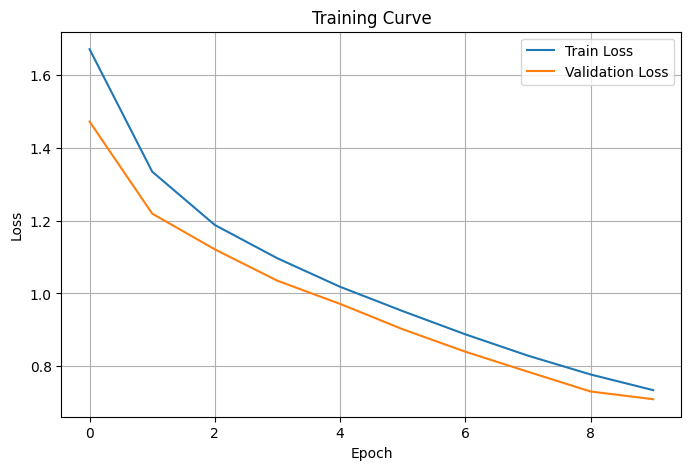

100%|██████████| 50/50 [00:32<00:00,  1.54it/s]


Epoch [11/30] | Train: 0.6891 | Val: 0.6599


100%|██████████| 50/50 [00:32<00:00,  1.52it/s]


Epoch [12/30] | Train: 0.6488 | Val: 0.6621


100%|██████████| 50/50 [00:33<00:00,  1.50it/s]


...

Epoch [18/30] | Train: 0.4822 | Val: 0.4624


100%|██████████| 50/50 [00:32<00:00,  1.54it/s]


Epoch [19/30] | Train: 0.4695 | Val: 0.4607


100%|██████████| 50/50 [00:32<00:00,  1.55it/s]


Epoch [20/30] | Train: 0.4522 | Val: 0.5194


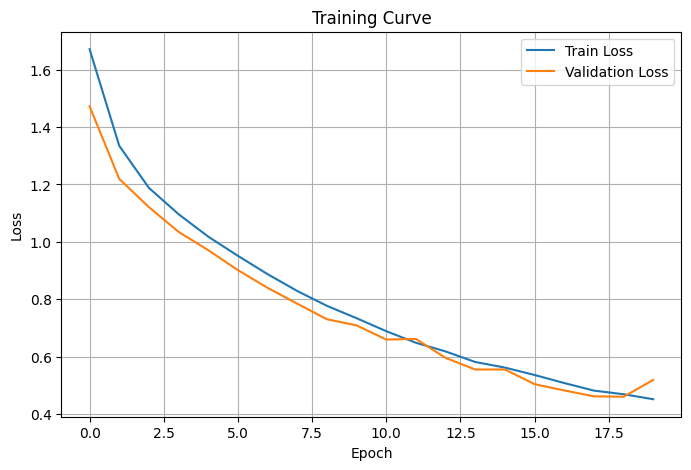

100%|██████████| 50/50 [00:32<00:00,  1.53it/s]


Epoch [21/30] | Train: 0.4424 | Val: 0.4344


100%|██████████| 50/50 [00:32<00:00,  1.56it/s]


Epoch [22/30] | Train: 0.4202 | Val: 0.4259


100%|██████████| 50/50 [00:31<00:00,  1.56it/s]


...

Epoch [28/30] | Train: 0.3514 | Val: 0.3689


100%|██████████| 50/50 [00:31<00:00,  1.59it/s]


Epoch [29/30] | Train: 0.3454 | Val: 0.3671


100%|██████████| 50/50 [00:31<00:00,  1.60it/s]


Epoch [30/30] | Train: 0.3345 | Val: 0.3617


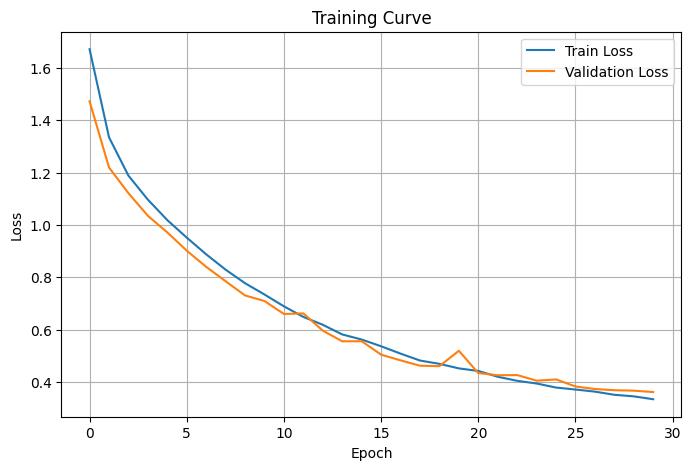

In [ ]:
epochs = 30
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(train_loader)
    val_loss   = val_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if (epoch + 1) % 10 == 0:
        plt.figure(figsize=(8,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Curve")
        plt.legend()
        plt.grid(True)
        plt.show()


torch.save(model.state_dict(), "unet_model.pth")

#### Best learning rate


Début entraînement avec learning rate = 0.005


  0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_6619/2059851705.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 50/50 [09:49<00:00, 11.80s/it]


LR=0.005 | Epoch [1/100] | Train: 1.1829 | Val: 1.0338


100%|██████████| 50/50 [00:31<00:00,  1.59it/s]


LR=0.005 | Epoch [2/100] | Train: 0.7989 | Val: 0.9231


...

LR=0.005 | Epoch [8/100] | Train: 0.3888 | Val: 0.6104


100%|██████████| 50/50 [00:31<00:00,  1.60it/s]


LR=0.005 | Epoch [9/100] | Train: 0.3751 | Val: 0.4612


100%|██████████| 50/50 [00:31<00:00,  1.60it/s]


LR=0.005 | Epoch [10/100] | Train: 0.3756 | Val: 0.3681


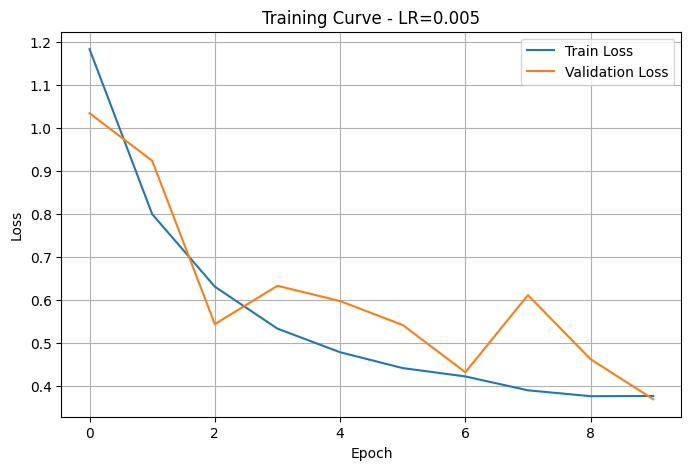

100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


LR=0.005 | Epoch [11/100] | Train: 0.3505 | Val: 0.4025


100%|██████████| 50/50 [00:30<00:00,  1.63it/s]


LR=0.005 | Epoch [12/100] | Train: 0.3399 | Val: 0.5545


100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


...

LR=0.005 | Epoch [18/100] | Train: 0.2936 | Val: 0.2800


100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


LR=0.005 | Epoch [19/100] | Train: 0.2821 | Val: 0.2876


100%|██████████| 50/50 [00:30<00:00,  1.66it/s]


LR=0.005 | Epoch [20/100] | Train: 0.2772 | Val: 0.3039


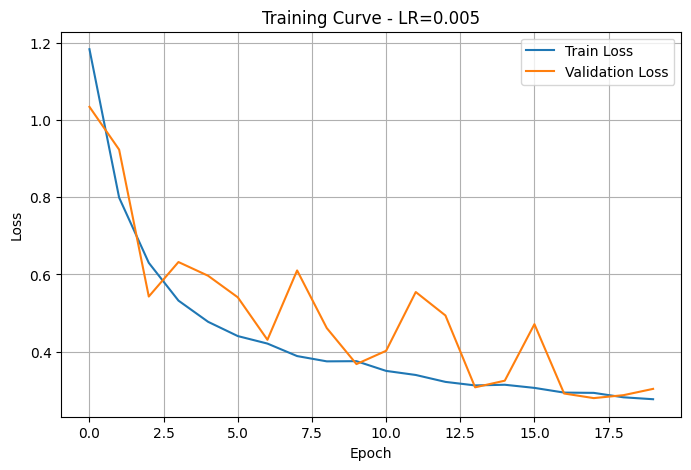

100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


LR=0.005 | Epoch [21/100] | Train: 0.2762 | Val: 0.3193


100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


LR=0.005 | Epoch [22/100] | Train: 0.2691 | Val: 0.3314


100%|██████████| 50/50 [00:30<00:00,  1.61it/s]


...

LR=0.005 | Epoch [28/100] | Train: 0.2462 | Val: 0.2594


100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


LR=0.005 | Epoch [29/100] | Train: 0.2458 | Val: 0.2713


100%|██████████| 50/50 [00:29<00:00,  1.68it/s]


LR=0.005 | Epoch [30/100] | Train: 0.2479 | Val: 0.2700


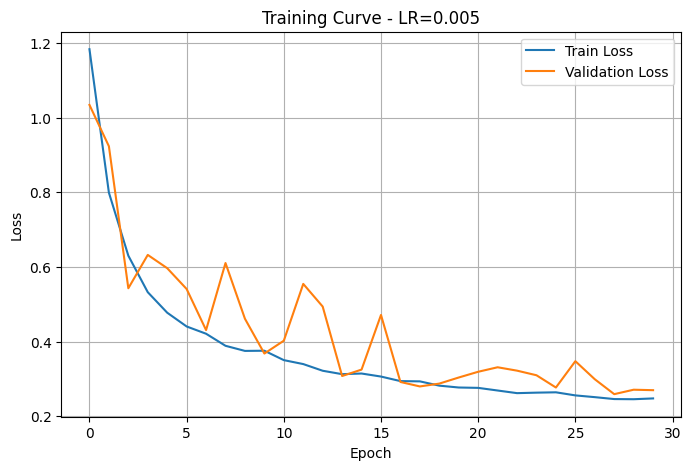

100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


LR=0.005 | Epoch [31/100] | Train: 0.2369 | Val: 0.2777


100%|██████████| 50/50 [00:30<00:00,  1.66it/s]


LR=0.005 | Epoch [32/100] | Train: 0.2342 | Val: 0.2659


100%|██████████| 50/50 [00:29<00:00,  1.68it/s]


...

100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


LR=0.005 | Epoch [38/100] | Train: 0.2124 | Val: 0.2804

Early stopping déclenché pour LR=0.005 à l'epoch 38
Aucune amélioration significative de la val_loss depuis 10 epochs.

 Fin entraînement LR=0.005
Best val loss: 0.2594 à l'epoch 28
Nombre d'epochs exécutées: 38
Best model saved: /content/drive/MyDrive/RL/camus_lr_search/best_unet_lr_0.005.pth
Last model saved: /content/drive/MyDrive/RL/camus_lr_search/last_unet_lr_0.005.pth
History saved: /content/drive/MyDrive/RL/camus_lr_search/history_lr_0.005.csv

Début entraînement avec learning rate = 0.001


100%|██████████| 50/50 [00:31<00:00,  1.60it/s]


LR=0.001 | Epoch [1/100] | Train: 1.5168 | Val: 1.1353


100%|██████████| 50/50 [00:31<00:00,  1.59it/s]


In [ ]:
# Learnin rates
learning_rates = [5e-3, 1e-3, 5e-4, 5e-5, 1e-5]
epochs = 100
patience = 10
min_delta = 1e-4

save_dir = "/content/drive/MyDrive/RL/camus_lr_search"
os.makedirs(save_dir, exist_ok=True)

all_results = []

# loop
for lr in learning_rates:
    print("\n" + "="*70)
    print(f"Début entraînement avec learning rate = {lr}")
    print("="*70)

    # model
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    globals()["model"] = model
    globals()["optimizer"] = optimizer
    globals()["criterion"] = criterion

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_model_path = os.path.join(save_dir, f"best_unet_lr_{lr}.pth")
    last_model_path = os.path.join(save_dir, f"last_unet_lr_{lr}.pth")
    history_csv_path = os.path.join(save_dir, f"history_lr_{lr}.csv")

    epochs_no_improve = 0
    stopped_early = False

    for epoch in range(epochs):
        train_loss = train_epoch(train_loader)
        val_loss   = val_epoch(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"LR={lr} | Epoch [{epoch+1}/{epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        # best model
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            epochs_no_improve += 1

        # plot
        if (epoch + 1) % 10 == 0:
            plt.figure(figsize=(8, 5))
            plt.plot(train_losses, label="Train Loss")
            plt.plot(val_losses, label="Validation Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Training Curve - LR={lr}")
            plt.legend()
            plt.grid(True)
            plt.show()

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping déclenché pour LR={lr} à l'epoch {epoch+1}")
            print(f"Aucune amélioration significative de la val_loss depuis {patience} epochs.")
            stopped_early = True
            break

    torch.save(model.state_dict(), last_model_path)

    hist_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses
    })
    hist_df.to_csv(history_csv_path, index=False)

    all_results.append({
        "learning_rate": lr,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_ran": len(train_losses),
        "stopped_early": stopped_early,
        "best_model_path": best_model_path,
        "last_model_path": last_model_path,
        "history_csv": history_csv_path
    })

    print(f"\n Fin entraînement LR={lr}")
    print(f"Best val loss: {best_val_loss:.4f} à l'epoch {best_epoch}")
    print(f"Nombre d'epochs exécutées: {len(train_losses)}")
    print(f"Best model saved: {best_model_path}")
    print(f"Last model saved: {last_model_path}")
    print(f"History saved: {history_csv_path}")


results_df = pd.DataFrame(all_results).sort_values(by="best_val_loss", ascending=True).reset_index(drop=True)

summary_path = os.path.join(save_dir, "lr_search_summary.csv")
results_df.to_csv(summary_path, index=False)

print("\n" + "="*70)
print("Recherche des learning rates terminée")
print("="*70)
print(results_df)
print(f"\nRésumé sauvegardé ici : {summary_path}")

In [ ]:
best_row = results_df.iloc[0]
print("\nMeilleur lr:")
print(best_row)

### Test

In [ ]:
@torch.no_grad()
def dice_per_class(pred, target, num_classes=4, eps=1e-6):
    dices = []

    pred = torch.argmax(pred, dim=1)

    for c in range(1, num_classes):  # skip background
        pred_c = (pred == c).float()
        target_c = (target == c).float()

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()

        dice = (2 * intersection + eps) / (union + eps)
        dices.append(dice.item())

    return dices


In [ ]:
def evaluate(model, loader):
    model.eval()

    dice_scores = {1: [], 2: [], 3: []}

    for x, y in tqdm(loader, desc="Testing"):
        x, y = x.to(device), y.to(device)

        with torch.cuda.amp.autocast():
            preds = model(x)

        batch_dice = dice_per_class(preds, y)

        for i, c in enumerate([1,2,3]):
            dice_scores[c].append(batch_dice[i])

    return {c: np.mean(v) for c, v in dice_scores.items()}


In [ ]:
dice_results = evaluate(model, test_loader)

print("\n===== TEST RESULTS =====")
print(f"LV Cavity Dice:   {dice_results[1]:.4f}")
print(f"Myocardium Dice: {dice_results[2]:.4f}")
print(f"Left Atrium Dice:{dice_results[3]:.4f}")


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipython-input-1316962444.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Testing: 100%|██████████| 13/13 [00:07<00:00,  1.75it/s]


===== TEST RESULTS =====
LV Cavity Dice:   0.9103
Myocardium Dice: 0.7980
Left Atrium Dice:0.8343


### SV and EF

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
seg_model = UNet().to(device)

ckpt_path = "/content/drive/MyDrive/RL/unet_model.pth"

seg_model.load_state_dict(torch.load(ckpt_path, map_location=device))
seg_model.eval()

print(" U-Net chargé :", ckpt_path)

 U-Net chargé : /content/drive/MyDrive/RL/unet_model.pth


In [ ]:


def normalize_img(img):
    img = img.astype(np.float32)
    return (img - img.mean()) / (img.std() + 1e-8)

@torch.no_grad()
def predict_lv_mask_orig(seg_model, img_np, orig_shape, img_size=192, lv_class=1, device="cuda"):
    seg_model.eval()

    img_np = normalize_img(img_np)
    x = torch.from_numpy(img_np)[None, None].float().to(device)          # (1,1,H0,W0)
    x_small = F.interpolate(x, size=(img_size, img_size), mode="bilinear", align_corners=False)

    logits = seg_model(x_small)                                          # (1,C,h,w)
    pred_cls = logits.argmax(dim=1)[0]                                   # (h,w)
    mask_small = (pred_cls == lv_class).float()[None, None]              # (1,1,h,w)

    mask_orig = F.interpolate(mask_small, size=orig_shape, mode="nearest")[0,0]
    return mask_orig.cpu().numpy().astype(np.uint8)

def compute_volume_from_mask(mask, spacing=(1.0, 1.0), lv_class=1):
    lv = (mask == lv_class).astype(np.float32)
    area = lv.sum()
    pixel_area = spacing[0] * spacing[1]
    return float(area * pixel_area)

@torch.no_grad()
def evaluate_sv_ef_from_testloader(seg_model, test_loader, device="cuda", lv_class=1):
    seg_model.eval()

    if not hasattr(test_loader.dataset, "samples"):
        raise AttributeError(
            "test_loader.dataset n'a pas l'attribut 'samples'. "
            "Il faut vérifier dans SubsetCAMUS comment sont stockés (pid, view, phase)."
        )

    samples = test_loader.dataset.samples

    patient_data = defaultdict(lambda: {"gt": {}, "pred": {}})
    global_idx = 0

    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)

        logits = seg_model(batch_x)

        if logits.shape[1] > 1:
            batch_pred = logits.argmax(dim=1).cpu().numpy()
        else:
            batch_pred = (torch.sigmoid(logits).squeeze(1) > 0.5).cpu().numpy().astype(np.uint8)

        batch_y = batch_y.cpu().numpy()

        B = batch_x.shape[0]

        for i in range(B):
            pid, view, phase = samples[global_idx]
            global_idx += 1

            gt_mask = batch_y[i]
            pred_mask = batch_pred[i]

            vol_gt = compute_volume_from_mask(gt_mask, spacing=(1.0, 1.0), lv_class=lv_class)
            vol_pred = compute_volume_from_mask(pred_mask, spacing=(1.0, 1.0), lv_class=lv_class)

            key = f"{view}_{phase}"
            patient_data[pid]["gt"][key] = vol_gt
            patient_data[pid]["pred"][key] = vol_pred

    all_targets = []
    all_preds = []

    needed = ["2CH_ED", "2CH_ES", "4CH_ED", "4CH_ES"]

    for pid, vals in patient_data.items():
        if not all(k in vals["gt"] for k in needed):
            continue
        if not all(k in vals["pred"] for k in needed):
            continue

        EDV_gt = (vals["gt"]["2CH_ED"] + vals["gt"]["4CH_ED"]) / 2.0
        ESV_gt = (vals["gt"]["2CH_ES"] + vals["gt"]["4CH_ES"]) / 2.0
        SV_gt = EDV_gt - ESV_gt
        EF_gt = SV_gt / (EDV_gt + 1e-8)

        EDV_pred = (vals["pred"]["2CH_ED"] + vals["pred"]["4CH_ED"]) / 2.0
        ESV_pred = (vals["pred"]["2CH_ES"] + vals["pred"]["4CH_ES"]) / 2.0
        SV_pred = EDV_pred - ESV_pred
        EF_pred = SV_pred / (EDV_pred + 1e-8)

        all_targets.append([SV_gt, EF_gt])
        all_preds.append([SV_pred, EF_pred])

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)

    sv_gt = all_targets[:, 0]
    ef_gt = all_targets[:, 1]
    sv_pred = all_preds[:, 0]
    ef_pred = all_preds[:, 1]

    sv_mae = mean_absolute_error(sv_gt, sv_pred)
    ef_mae = mean_absolute_error(ef_gt, ef_pred)

    sv_mse = mean_squared_error(sv_gt, sv_pred)
    ef_mse = mean_squared_error(ef_gt, ef_pred)

    sv_rmse = np.sqrt(sv_mse)
    ef_rmse = np.sqrt(ef_mse)

    sv_corr = pearsonr(sv_gt, sv_pred)[0] if len(sv_gt) > 1 else np.nan
    ef_corr = pearsonr(ef_gt, ef_pred)[0] if len(ef_gt) > 1 else np.nan

    sv_gt_median = np.median(sv_gt)
    sv_gt_std = np.std(sv_gt)
    sv_pred_median = np.median(sv_pred)
    sv_pred_std = np.std(sv_pred)

    ef_gt_median = np.median(ef_gt)
    ef_gt_std = np.std(ef_gt)
    ef_pred_median = np.median(ef_pred)
    ef_pred_std = np.std(ef_pred)

    print("\n===== TEST RESULTS =====")

    print("\n--- Stroke Volume (SV) ---")
    print(f"GT      : {sv_gt_median:.2f} ± {sv_gt_std:.2f}")
    print(f"Pred    : {sv_pred_median:.2f} ± {sv_pred_std:.2f}")
    print(f"MAE     : {sv_mae:.2f}")
    print(f"MSE     : {sv_mse:.2f}")
    print(f"RMSE    : {sv_rmse:.2f}")
    print(f"Corr    : {sv_corr:.3f}")

    print("\n--- Ejection Fraction (EF) ---")
    print(f"GT      : {ef_gt_median:.3f} ± {ef_gt_std:.3f}")
    print(f"Pred    : {ef_pred_median:.3f} ± {ef_pred_std:.3f}")
    print(f"MAE     : {ef_mae:.3f}")
    print(f"MSE     : {ef_mse:.3f}")
    print(f"RMSE    : {ef_rmse:.3f}")
    print(f"Corr    : {ef_corr:.3f}")

    return {
        "all_targets": all_targets,
        "all_preds": all_preds,
        "patient_data": patient_data,
        "sv_mae": sv_mae,
        "ef_mae": ef_mae,
        "sv_mse": sv_mse,
        "ef_mse": ef_mse,
        "sv_rmse": sv_rmse,
        "ef_rmse": ef_rmse,
        "sv_corr": sv_corr,
        "ef_corr": ef_corr,
    }

In [ ]:
results_sv_ef = evaluate_sv_ef_from_testloader(
    seg_model=seg_model,
    test_loader=test_loader,
    device=device,
    lv_class=1
)


===== TEST RESULTS =====

--- Stroke Volume (SV) ---
GT      : 1539.75 ± 525.29
Pred    : 1456.50 ± 508.13
MAE     : 257.63
MSE     : 115938.26
RMSE    : 340.50
Corr    : 0.837

--- Ejection Fraction (EF) ---
GT      : 0.377 ± 0.078
Pred    : 0.335 ± 0.089
MAE     : 0.059
MSE     : 0.006
RMSE    : 0.078
Corr    : 0.696


In [ ]:
save_txt = "/content/drive/MyDrive/RL/CAMUS_public/sv_ef_metrics.txt"

with open(save_txt, "w") as f:
    f.write("===== TEST RESULTS =====\n\n")

    f.write("--- Stroke Volume (SV) ---\n")
    f.write(f"GT      : {np.median(sv_gt):.2f} ± {np.std(sv_gt):.2f}\n")
    f.write(f"Pred    : {np.median(sv_pred):.2f} ± {np.std(sv_pred):.2f}\n")
    f.write(f"MAE     : {results_sv_ef['sv_mae']:.2f}\n")
    f.write(f"MSE     : {results_sv_ef['sv_mse']:.2f}\n")
    f.write(f"RMSE    : {results_sv_ef['sv_rmse']:.2f}\n")
    f.write(f"Corr    : {results_sv_ef['sv_corr']:.3f}\n\n")

    f.write("--- Ejection Fraction (EF) ---\n")
    f.write(f"GT      : {np.median(ef_gt):.3f} ± {np.std(ef_gt):.3f}\n")
    f.write(f"Pred    : {np.median(ef_pred):.3f} ± {np.std(ef_pred):.3f}\n")
    f.write(f"MAE     : {results_sv_ef['ef_mae']:.3f}\n")
    f.write(f"MSE     : {results_sv_ef['ef_mse']:.3f}\n")
    f.write(f"RMSE    : {results_sv_ef['ef_rmse']:.3f}\n")
    f.write(f"Corr    : {results_sv_ef['ef_corr']:.3f}\n")

print("Métriques sauvegardées dans :", save_txt)

In [ ]:
df_results = pd.DataFrame({
    "SV_GT": sv_gt,
    "SV_Pred": sv_pred,
    "EF_GT": ef_gt,
    "EF_Pred": ef_pred,
})

save_csv = "/content/drive/MyDrive/RL/CAMUS_public/sv_ef_predictions.csv"
df_results.to_csv(save_csv, index=False)

print(" CSV sauvegardé dans :", save_csv)
df_results.head()

In [ ]:
np.save("/content/drive/MyDrive/RL/CAMUS_public/all_targets_sv_ef.npy", all_targets)
np.save("/content/drive/MyDrive/RL/CAMUS_public/all_preds_sv_ef.npy", all_preds)

print(" Tableaux numpy sauvegardés")

## **3- Regression**

### Dataset

In [ ]:
class CAMUSRegressionDataset(Dataset):
    def __init__(self, root_dir, patient_list, img_size=192):
        self.root_dir = root_dir
        self.patient_list = patient_list
        self.img_size = img_size

    def load_nii(self, path):
        return nib.load(path).get_fdata()

    def compute_volume(self, mask, spacing):
        """
        Simple pixel-based volume approximation:
        volume = area * pixel_spacing_x * pixel_spacing_y
        """
        lv = (mask == 1).astype(np.float32)  # LV cavity class
        area = lv.sum()
        pixel_area = spacing[0] * spacing[1]
        return area * pixel_area

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        pid = self.patient_list[idx]
        pdir = os.path.join(self.root_dir, pid)

        imgs = []
        volumes = {}

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img_path = os.path.join(pdir, f"{pid}_{view}_{phase}.nii.gz")
                mask_path = os.path.join(pdir, f"{pid}_{view}_{phase}_gt.nii.gz")

                img_nii = nib.load(img_path)
                img = img_nii.get_fdata()
                mask = self.load_nii(mask_path)

                spacing = img_nii.header.get_zooms()

                # Normalize
                img = (img - img.mean()) / (img.std() + 1e-8)

                img = torch.tensor(img).unsqueeze(0).float()
                img = TF.resize(img, (self.img_size, self.img_size),
                                interpolation=TF.InterpolationMode.BILINEAR)

                imgs.append(img)

                volumes[f"{view}_{phase}"] = self.compute_volume(mask, spacing)

        EDV = (volumes["2CH_ED"] + volumes["4CH_ED"]) / 2
        ESV = (volumes["2CH_ES"] + volumes["4CH_ES"]) / 2

        SV = EDV - ESV
        EF = SV / (EDV + 1e-8)

        x = torch.cat(imgs, dim=0)   # (4, H, W)
        y = torch.tensor([SV, EF], dtype=torch.float32)

        return x, y

In [ ]:
root = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti/"
train_ds = CAMUSRegressionDataset(root, train_ids)
val_ds   = CAMUSRegressionDataset(root, val_ids)
test_ds  = CAMUSRegressionDataset(root, test_ids)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

### Train

In [ ]:
class EFRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # SV and EF
        )

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = EFRegressor().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(x)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
@torch.no_grad()
def val_epoch(loader):
    model.eval()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = criterion(preds, y)
        total_loss += loss.item()

    return total_loss / len(loader)

Epoch [1/120] | Train: 623290.3688 | Val: 661333.2991
Epoch [2/120] | Train: 621744.7412 | Val: 659295.0536
Epoch [3/120] | Train: 619451.7425 | Val: 656431.5982
Epoch [4/120] | Train: 616043.4762 | Val: 651344.1875
Epoch [5/120] | Train: 611355.2625 | Val: 648736.5357
Epoch [6/120] | Train: 605219.9213 | Val: 640768.7232
Epoch [7/120] | Train: 597456.7788 | Val: 631727.0714
Epoch [8/120] | Train: 587923.9613 | Val: 613882.7946
Epoch [9/120] | Train: 576507.8912 | Val: 606898.9821
Epoch [10/120] | Train: 563033.4875 | Val: 582406.2500


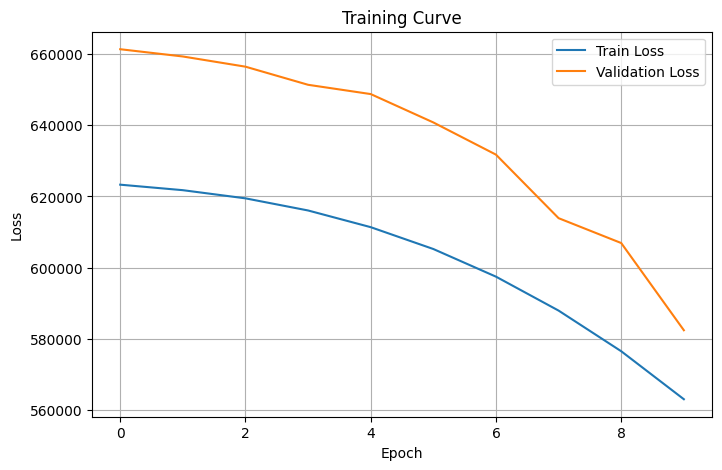

Epoch [11/120] | Train: 547698.8762 | Val: 585026.4643
Epoch [12/120] | Train: 530110.4962 | Val: 560492.6295
Epoch [13/120] | Train: 510632.7825 | Val: 539645.0491
Epoch [14/120] | Train: 489130.1213 | Val: 477020.4911
Epoch [15/120] | Train: 465852.3719 | Val: 497225.3125
Epoch [16/120] | Train: 440872.7712 | Val: 424682.8170
Epoch [17/120] | Train: 414406.8506 | Val: 459495.7545
Epoch [18/120] | Train: 386848.4750 | Val: 429540.6518
Epoch [19/120] | Train: 358551.1506 | Val: 347016.8683
Epoch [20/120] | Train: 329219.3387 | Val: 310159.2478


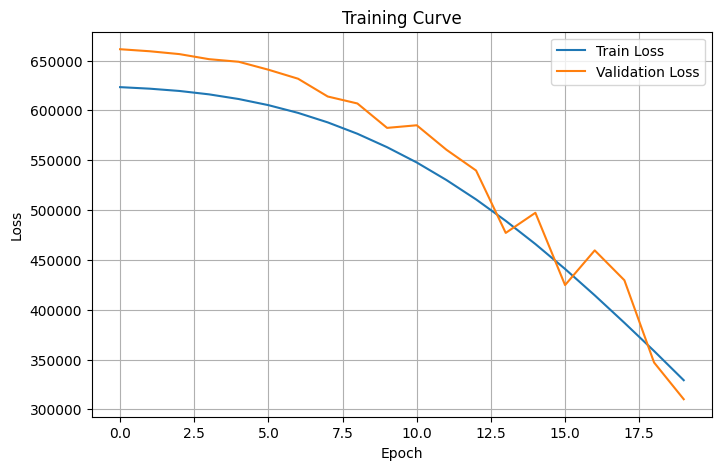

Epoch [21/120] | Train: 300271.7269 | Val: 284065.9933
Epoch [22/120] | Train: 271353.0453 | Val: 323412.2634
Epoch [23/120] | Train: 242986.4775 | Val: 201586.9007
Epoch [24/120] | Train: 216268.0072 | Val: 226920.1763
Epoch [25/120] | Train: 189975.9175 | Val: 188157.3538
Epoch [26/120] | Train: 166351.2219 | Val: 153537.9877
Epoch [27/120] | Train: 144319.3050 | Val: 125212.1858
Epoch [28/120] | Train: 124397.3939 | Val: 144922.2020
Epoch [29/120] | Train: 106627.5941 | Val: 106969.7626
Epoch [30/120] | Train: 91483.0807 | Val: 101628.4950


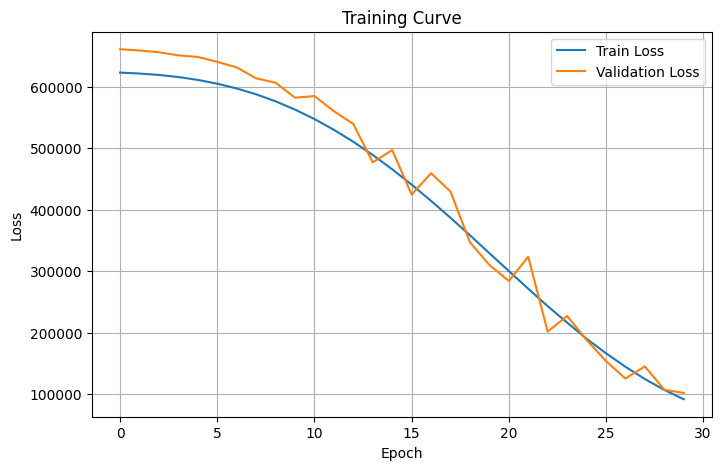

Epoch [31/120] | Train: 79219.8734 | Val: 102717.8747
Epoch [32/120] | Train: 68621.0263 | Val: 60859.8757
Epoch [33/120] | Train: 59436.9523 | Val: 117702.9286
Epoch [34/120] | Train: 52854.9772 | Val: 47910.4514
Epoch [35/120] | Train: 47277.7563 | Val: 59490.6753
Epoch [36/120] | Train: 43482.9441 | Val: 79287.1737
Epoch [37/120] | Train: 39506.8211 | Val: 33528.0070
Epoch [38/120] | Train: 36185.8594 | Val: 51139.6657
Epoch [39/120] | Train: 37128.6451 | Val: 60151.9360
Epoch [40/120] | Train: 32661.4425 | Val: 58561.0265


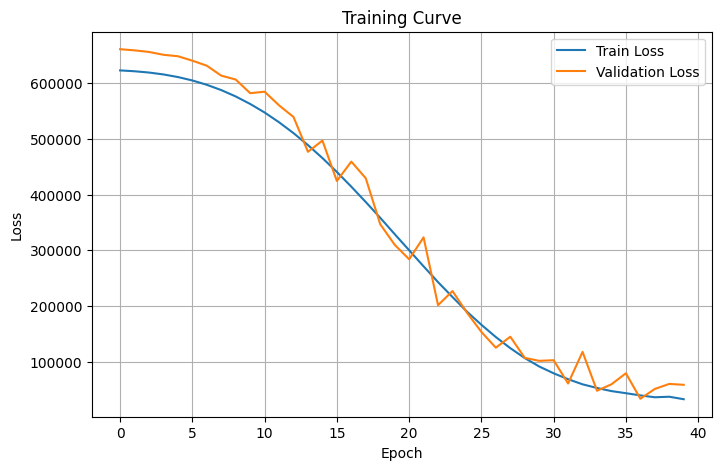

Epoch [41/120] | Train: 31494.4104 | Val: 37130.1247
Epoch [42/120] | Train: 27786.9940 | Val: 29926.8746
Epoch [43/120] | Train: 29292.0607 | Val: 58208.6178
Epoch [44/120] | Train: 27103.6185 | Val: 32960.1855
Epoch [45/120] | Train: 27477.9521 | Val: 35163.4830
Epoch [46/120] | Train: 27289.8413 | Val: 89712.0879
Epoch [47/120] | Train: 26153.7182 | Val: 44499.8885
Epoch [48/120] | Train: 28102.8755 | Val: 36467.9544
Epoch [49/120] | Train: 26673.5173 | Val: 39309.7991
Epoch [50/120] | Train: 26788.6191 | Val: 32982.6731


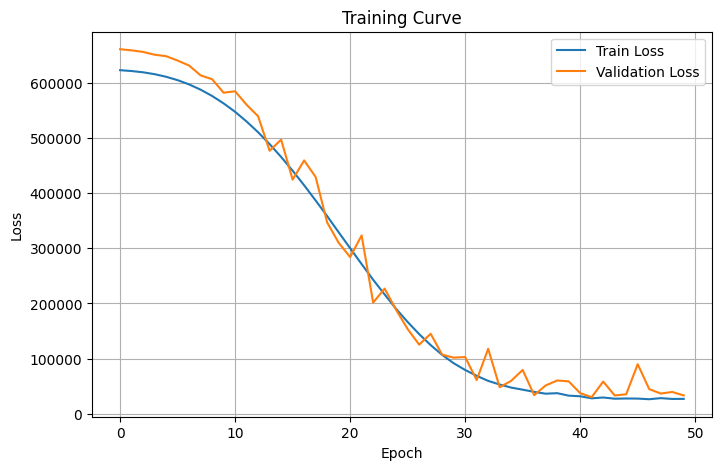

Epoch [51/120] | Train: 25171.0886 | Val: 30527.2049
Epoch [52/120] | Train: 26516.2162 | Val: 55378.3772
Early stopping triggered.


In [ ]:
epochs = 120
patience = 10
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(train_loader)
    val_loss   = val_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "unet_model_direct.pth")  # save best model
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

    if (epoch + 1) % 10 == 0:
        plt.figure(figsize=(8,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

### Test

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)

        preds = model(x)
        preds = preds.cpu().numpy()

        all_preds.append(preds)
        all_targets.append(y.numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    # Metrics
    sv_mae = mean_absolute_error(all_targets[:,0], all_preds[:,0])
    ef_mae = mean_absolute_error(all_targets[:,1], all_preds[:,1])

    sv_corr = pearsonr(all_targets[:,0], all_preds[:,0])[0]
    ef_corr = pearsonr(all_targets[:,1], all_preds[:,1])[0]

    # Statistics
    sv_gt_median = np.median(all_targets[:,0])
    sv_gt_std    = np.std(all_targets[:,0])

    sv_pred_median = np.median(all_preds[:,0])
    sv_pred_std    = np.std(all_preds[:,0])

    ef_gt_median = np.median(all_targets[:,1])
    ef_gt_std    = np.std(all_targets[:,1])

    ef_pred_median = np.median(all_preds[:,1])
    ef_pred_std    = np.std(all_preds[:,1])

    print("\n===== TEST RESULTS =====")

    print("\n--- Stroke Volume (SV) ---")
    print(f"GT      : {sv_gt_median:.2f} ± {sv_gt_std:.2f}")
    print(f"Pred    : {sv_pred_median:.2f} ± {sv_pred_std:.2f}")
    print(f"MAE     : {sv_mae:.2f}")
    print(f"Corr    : {sv_corr:.3f}")

    print("\n--- Ejection Fraction (EF) ---")
    print(f"GT      : {ef_gt_median:.3f} ± {ef_gt_std:.3f}")
    print(f"Pred    : {ef_pred_median:.3f} ± {ef_pred_std:.3f}")
    print(f"MAE     : {ef_mae:.3f}")
    print(f"Corr    : {ef_corr:.3f}")

In [ ]:
direct = DATA_DIR / "unet_model_direct.pth"

if direct.exists():
    print("Loading model")
    model = EFRegressor().to(device)
    ckpt_path = direct
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

evaluate(model, test_loader)

Loading model

===== TEST RESULTS =====

--- Stroke Volume (SV) ---
GT      : 1084.46 ± 236.38
Pred    : 1149.38 ± 139.84
MAE     : 198.59
Corr    : 0.271

--- Ejection Fraction (EF) ---
GT      : 0.377 ± 0.079
Pred    : 0.334 ± 0.049
MAE     : 0.065
Corr    : 0.552


## **4- Multi-model**

### Dataset

In [ ]:
class CAMUSMultiTaskDataset(Dataset):
    def __init__(self, root_dir, patient_list, img_size=192):
        self.root_dir = root_dir
        self.patient_list = patient_list
        self.img_size = img_size

    def load_nii(self, path):
        return nib.load(path).get_fdata()

    def compute_volume(self, mask, spacing):
        lv = (mask == 1).astype(np.float32)
        area = lv.sum()
        pixel_area = spacing[0] * spacing[1]
        return area * pixel_area

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        pid = self.patient_list[idx]
        pdir = os.path.join(self.root_dir, pid)

        imgs = []
        masks = []
        volumes = {}

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img_path = os.path.join(pdir, f"{pid}_{view}_{phase}.nii.gz")
                mask_path = os.path.join(pdir, f"{pid}_{view}_{phase}_gt.nii.gz")

                img_nii = nib.load(img_path)
                img = img_nii.get_fdata()
                mask = self.load_nii(mask_path)

                spacing = img_nii.header.get_zooms()

                img = (img - img.mean()) / (img.std() + 1e-8)

                img = torch.tensor(img).unsqueeze(0).float()
                mask = torch.tensor(mask).long()

                img = TF.resize(img, (self.img_size, self.img_size),
                                interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.resize(mask.unsqueeze(0).float(),
                                 (self.img_size, self.img_size),
                                 interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()

                imgs.append(img)
                masks.append(mask)

                volumes[f"{view}_{phase}"] = self.compute_volume(mask.numpy(), spacing)

        EDV = (volumes["2CH_ED"] + volumes["4CH_ED"]) / 2
        ESV = (volumes["2CH_ES"] + volumes["4CH_ES"]) / 2
        SV = EDV - ESV
        EF = SV / (EDV + 1e-8)

        x = torch.cat(imgs, dim=0)             # (4,H,W)
        y_seg = torch.stack(masks)             # (4,H,W)
        y_sv = torch.tensor([SV], dtype=torch.float32)
        y_ef = torch.tensor([EF], dtype=torch.float32)

        return x, y_seg, y_ef

In [ ]:
train_ds = CAMUSMultiTaskDataset(root, train_ids)
val_ds   = CAMUSMultiTaskDataset(root, val_ids)
test_ds  = CAMUSMultiTaskDataset(root, test_ids)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

### Train

In [ ]:
class MultiTaskUNet(nn.Module):
    def __init__(self, base=32, num_classes=4):
        super().__init__()

        # Encoder
        self.d1 = DoubleConv(4, base)
        self.d2 = DoubleConv(base, base*2)
        self.d3 = DoubleConv(base*2, base*4)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Decoder (segmentation)
        self.u1 = DoubleConv(base*4 + base*2, base*2)
        self.u2 = DoubleConv(base*2 + base, base)
        self.out_seg = nn.Conv2d(base, 4 * num_classes, 1)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base*4, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # SV only
        )

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2))

        # Segmentation branch
        x_up = self.up(c3)
        x_up = self.u1(torch.cat([x_up, c2], dim=1))

        x_up = self.up(x_up)
        x_up = self.u2(torch.cat([x_up, c1], dim=1))

        seg_out = self.out_seg(x_up)

        # reshape
        B, C, H, W = seg_out.shape
        seg_out = seg_out.view(B, 4, 4, H, W)

        # Regression branch
        sv_out = self.reg_head(c3)

        return seg_out, sv_out

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiTaskUNet().to(device)

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()
mse_loss = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

lambda_sv = 50

In [ ]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for x, y_seg, y_sv in loader:
        x = x.to(device)
        y_seg = y_seg.to(device)
        y_sv = y_sv.to(device)

        optimizer.zero_grad()

        seg_pred, sv_pred = model(x)

        B = y_seg.shape[0]
        # seg_pred = seg_pred.view(B*4, 4, seg_pred.shape[-2], seg_pred.shape[-1])
        # y_seg = y_seg.view(B*4, y_seg.shape[-2], y_seg.shape[-1])

        seg_pred = seg_pred.view(-1, 4, seg_pred.shape[-2], seg_pred.shape[-1])
        y_seg = y_seg.view(-1, y_seg.shape[-2], y_seg.shape[-1])

        loss_seg = ce_loss(seg_pred, y_seg) + dice_loss(seg_pred, y_seg)
        loss_sv = mse_loss(sv_pred, y_sv)

        loss = loss_seg + lambda_sv * loss_sv

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
@torch.no_grad()
def val_epoch(loader):
    model.eval()
    total_loss = 0

    for x, y_seg, y_sv in loader:
        x = x.to(device)
        y_seg = y_seg.to(device)
        y_sv = y_sv.to(device)

        seg_pred, sv_pred = model(x)

        seg_pred = seg_pred.view(-1, 4, seg_pred.shape[-2], seg_pred.shape[-1])
        y_seg = y_seg.view(-1, y_seg.shape[-2], y_seg.shape[-1])

        loss_seg = ce_loss(seg_pred, y_seg) + dice_loss(seg_pred, y_seg)
        loss_sv = mse_loss(sv_pred, y_sv)

        # print(loss_seg)
        # print(loss_sv)

        loss = loss_seg + lambda_sv * loss_sv

        total_loss += loss.item()

    return total_loss / len(loader)

Epoch [1/120] | Train: 5.8061 | Val: 3.8421
Epoch [2/120] | Train: 2.4254 | Val: 2.3332
Epoch [3/120] | Train: 2.2457 | Val: 2.1506
Epoch [4/120] | Train: 2.1518 | Val: 2.0984
Epoch [5/120] | Train: 2.0560 | Val: 2.0752
Epoch [6/120] | Train: 2.0281 | Val: 1.9714
Epoch [7/120] | Train: 1.9532 | Val: 1.9143
Epoch [8/120] | Train: 1.8843 | Val: 1.8433
Epoch [9/120] | Train: 1.8222 | Val: 1.7837
Epoch [10/120] | Train: 1.7460 | Val: 1.7463


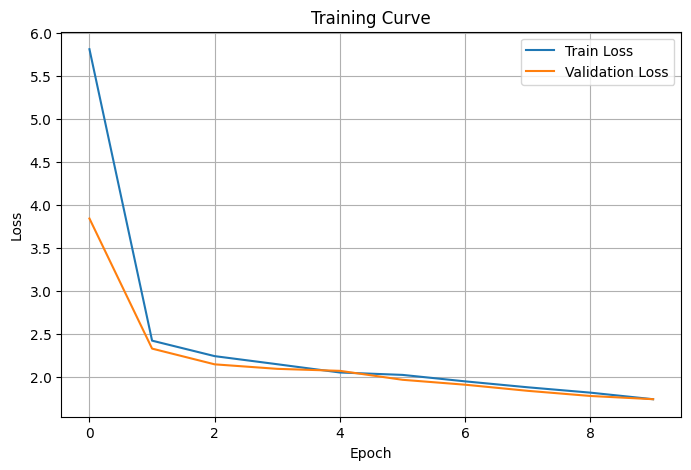

Epoch [11/120] | Train: 1.7588 | Val: 1.8715
Epoch [12/120] | Train: 1.6820 | Val: 1.8795
Epoch [13/120] | Train: 1.6557 | Val: 1.6335
Epoch [14/120] | Train: 1.5865 | Val: 1.5938
Epoch [15/120] | Train: 1.5446 | Val: 1.6057
Epoch [16/120] | Train: 1.5019 | Val: 1.5269
Epoch [17/120] | Train: 1.4560 | Val: 2.4519
Epoch [18/120] | Train: 1.4442 | Val: 1.5320
Epoch [19/120] | Train: 1.3734 | Val: 1.5667
Epoch [20/120] | Train: 1.3232 | Val: 1.5051


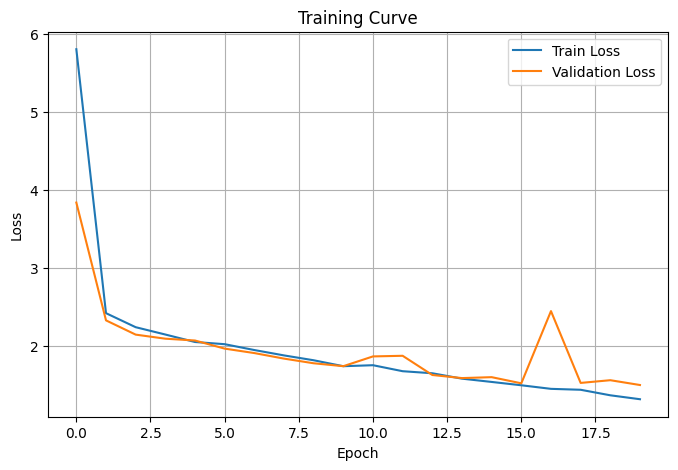

Epoch [21/120] | Train: 1.2946 | Val: 1.4088
Epoch [22/120] | Train: 1.2501 | Val: 1.8118
Epoch [23/120] | Train: 1.2340 | Val: 1.3086
Epoch [24/120] | Train: 1.2008 | Val: 1.5038
Epoch [25/120] | Train: 1.1481 | Val: 1.3289
Epoch [26/120] | Train: 1.1272 | Val: 1.2605
Epoch [27/120] | Train: 1.1730 | Val: 2.0605
Epoch [28/120] | Train: 1.0888 | Val: 1.2011
Epoch [29/120] | Train: 1.0465 | Val: 1.1752
Epoch [30/120] | Train: 1.0212 | Val: 1.3590


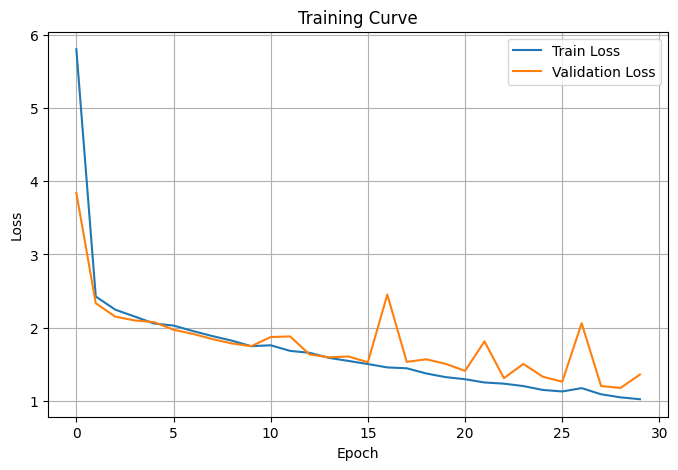

Epoch [31/120] | Train: 0.9871 | Val: 1.3718
Epoch [32/120] | Train: 0.9710 | Val: 1.1005
Epoch [33/120] | Train: 0.9320 | Val: 1.2692
Epoch [34/120] | Train: 0.9341 | Val: 1.8315
Epoch [35/120] | Train: 0.9004 | Val: 1.0482
Epoch [36/120] | Train: 0.8985 | Val: 1.0512
Epoch [37/120] | Train: 0.8497 | Val: 1.3996
Epoch [38/120] | Train: 0.8529 | Val: 1.0832
Epoch [39/120] | Train: 0.7934 | Val: 1.0749
Epoch [40/120] | Train: 0.8059 | Val: 0.9950


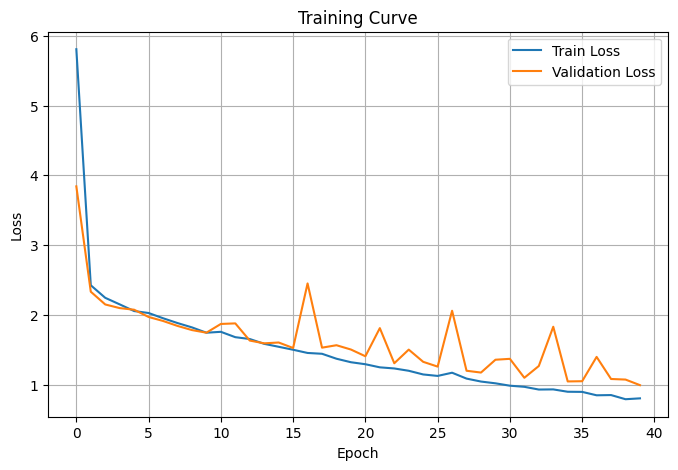

Epoch [41/120] | Train: 0.7914 | Val: 2.2870
Epoch [42/120] | Train: 0.7824 | Val: 0.9855
Epoch [43/120] | Train: 0.7372 | Val: 1.4021
Epoch [44/120] | Train: 0.7383 | Val: 0.9415
Epoch [45/120] | Train: 0.7096 | Val: 0.9668
Epoch [46/120] | Train: 0.6983 | Val: 1.3674
Epoch [47/120] | Train: 0.6746 | Val: 1.2111
Epoch [48/120] | Train: 0.6728 | Val: 0.9694
Epoch [49/120] | Train: 0.6606 | Val: 0.9286
Epoch [50/120] | Train: 0.6504 | Val: 1.0877


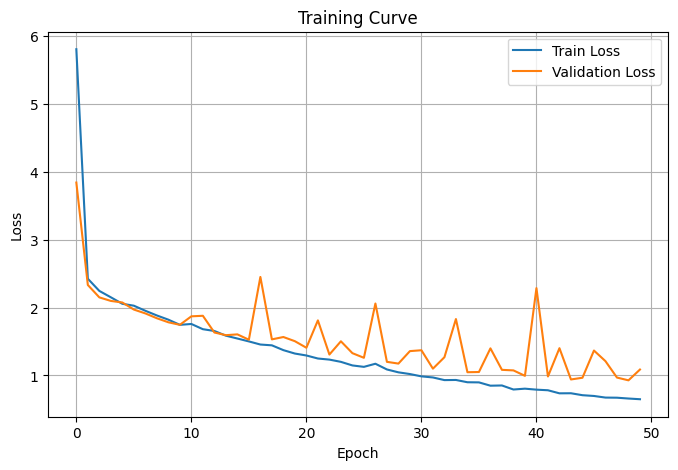

Epoch [51/120] | Train: 0.6722 | Val: 1.3548
Epoch [52/120] | Train: 0.6313 | Val: 0.8678
Epoch [53/120] | Train: 0.6339 | Val: 1.1225
Epoch [54/120] | Train: 0.6208 | Val: 1.0495
Epoch [55/120] | Train: 0.5964 | Val: 1.3051
Epoch [56/120] | Train: 0.5843 | Val: 1.0333
Epoch [57/120] | Train: 0.5676 | Val: 1.0494
Epoch [58/120] | Train: 0.5879 | Val: 0.8111
Epoch [59/120] | Train: 0.5505 | Val: 0.8624
Epoch [60/120] | Train: 0.5683 | Val: 0.7966


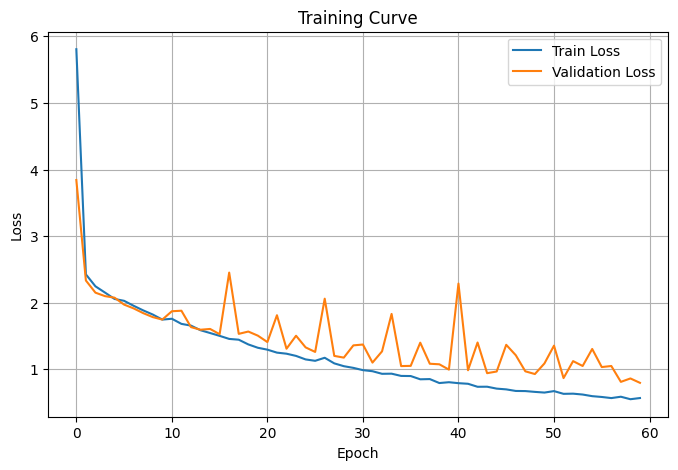

Epoch [61/120] | Train: 0.5333 | Val: 0.8485
Epoch [62/120] | Train: 0.5314 | Val: 0.7943
Epoch [63/120] | Train: 0.5223 | Val: 0.7787
Epoch [64/120] | Train: 0.5190 | Val: 0.8574
Epoch [65/120] | Train: 0.5220 | Val: 0.8283
Epoch [66/120] | Train: 0.5239 | Val: 0.8591
Epoch [67/120] | Train: 0.4835 | Val: 0.7762
Epoch [68/120] | Train: 0.5232 | Val: 1.7233
Epoch [69/120] | Train: 0.4933 | Val: 0.7475
Epoch [70/120] | Train: 0.5187 | Val: 0.8482


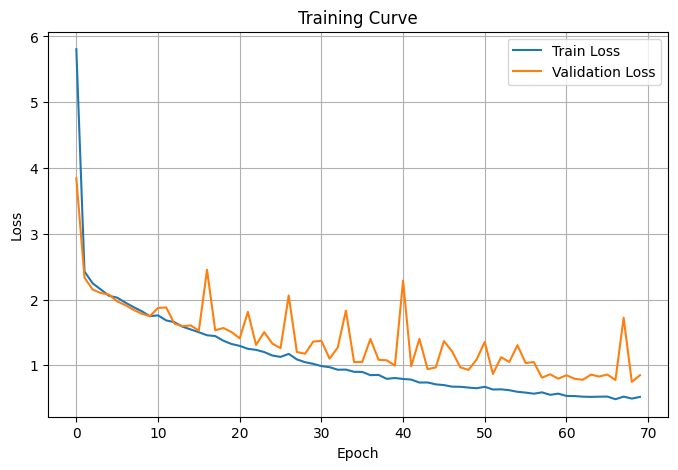

Epoch [71/120] | Train: 0.4995 | Val: 0.8223
Epoch [72/120] | Train: 0.4799 | Val: 0.7550
Epoch [73/120] | Train: 0.4740 | Val: 0.7401
Epoch [74/120] | Train: 0.5175 | Val: 1.5098
Epoch [75/120] | Train: 0.4961 | Val: 0.9978
Epoch [76/120] | Train: 0.4608 | Val: 0.8048
Epoch [77/120] | Train: 0.4903 | Val: 0.7620
Epoch [78/120] | Train: 0.4740 | Val: 0.8484
Epoch [79/120] | Train: 0.4545 | Val: 0.8959
Epoch [80/120] | Train: 0.4353 | Val: 0.7165


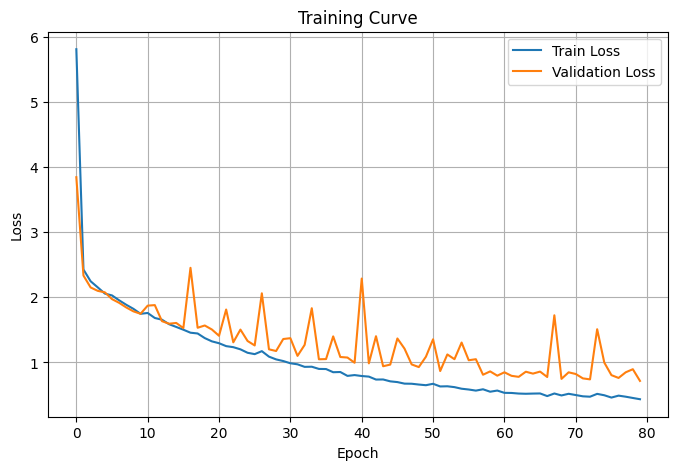

Epoch [81/120] | Train: 0.4306 | Val: 0.7477
Epoch [82/120] | Train: 0.4227 | Val: 0.6995
Epoch [83/120] | Train: 0.4280 | Val: 0.7209
Epoch [84/120] | Train: 0.4090 | Val: 1.2868
Epoch [85/120] | Train: 0.4257 | Val: 0.7508
Epoch [86/120] | Train: 0.4191 | Val: 0.7360
Epoch [87/120] | Train: 0.4619 | Val: 0.8722
Epoch [88/120] | Train: 0.4068 | Val: 0.8796
Epoch [89/120] | Train: 0.4207 | Val: 0.7407
Epoch [90/120] | Train: 0.4454 | Val: 0.7719


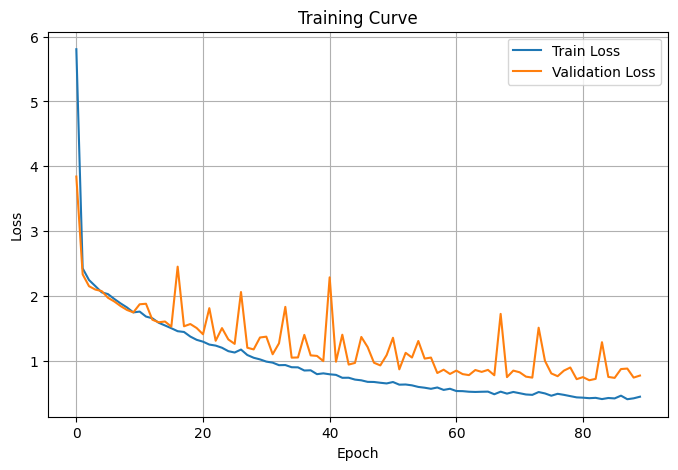

Epoch [91/120] | Train: 0.4099 | Val: 0.6885
Epoch [92/120] | Train: 0.3720 | Val: 0.6999
Epoch [93/120] | Train: 0.3912 | Val: 0.6965
Epoch [94/120] | Train: 0.3923 | Val: 0.7087
Epoch [95/120] | Train: 0.3706 | Val: 0.7075
Epoch [96/120] | Train: 0.3627 | Val: 0.6914
Epoch [97/120] | Train: 0.3434 | Val: 0.6706
Epoch [98/120] | Train: 0.3771 | Val: 0.7172
Epoch [99/120] | Train: 0.3720 | Val: 0.6897
Epoch [100/120] | Train: 0.3619 | Val: 0.7254


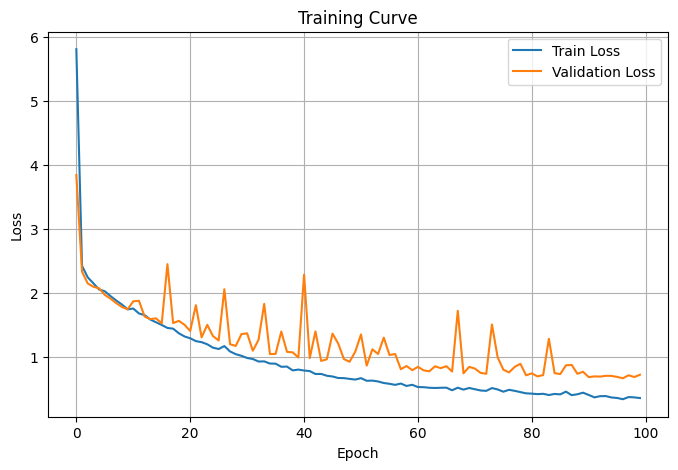

Epoch [101/120] | Train: 0.3738 | Val: 1.2542
Epoch [102/120] | Train: 0.3553 | Val: 0.6657
Epoch [103/120] | Train: 0.3706 | Val: 0.6771
Epoch [104/120] | Train: 0.3937 | Val: 0.6895
Epoch [105/120] | Train: 0.3520 | Val: 0.7607
Epoch [106/120] | Train: 0.3440 | Val: 0.6940
Epoch [107/120] | Train: 0.3424 | Val: 0.7909
Epoch [108/120] | Train: 0.3435 | Val: 0.9123
Epoch [109/120] | Train: 0.3478 | Val: 0.7055
Epoch [110/120] | Train: 0.3369 | Val: 0.6873


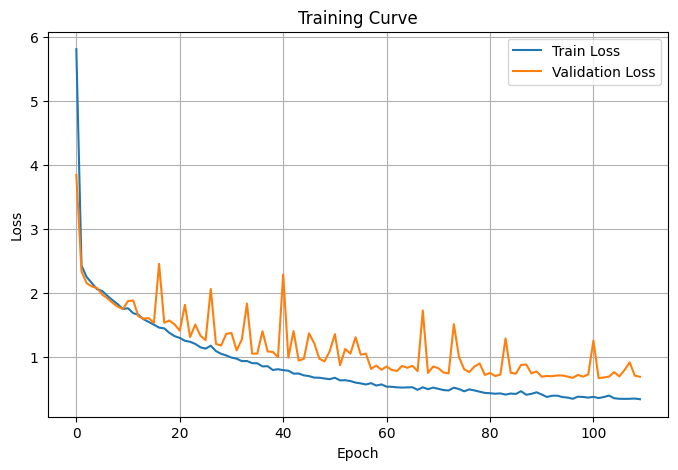

Epoch [111/120] | Train: 0.3514 | Val: 0.6377
Epoch [112/120] | Train: 0.3404 | Val: 0.6622
Epoch [113/120] | Train: 0.3240 | Val: 0.6813
Epoch [114/120] | Train: 0.3319 | Val: 0.8481
Epoch [115/120] | Train: 0.3360 | Val: 0.6871
Epoch [116/120] | Train: 0.3262 | Val: 0.6943
Epoch [117/120] | Train: 0.3230 | Val: 0.7010
Epoch [118/120] | Train: 0.3057 | Val: 0.6972
Epoch [119/120] | Train: 0.3274 | Val: 0.7219
Epoch [120/120] | Train: 0.3134 | Val: 0.7812


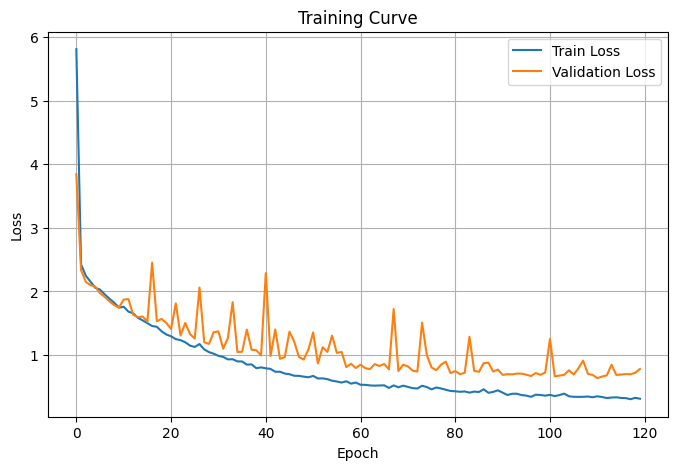

In [ ]:
epochs = 120
patience = 10
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(train_loader)
    val_loss   = val_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "unet_model_multi.pth")  # save best model
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

    if (epoch + 1) % 10 == 0:
        plt.figure(figsize=(8,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

### Test

In [ ]:
@torch.no_grad()
def evaluate(model,loader):
    model.eval()

    dice_scores = []
    ef_preds = []
    ef_targets = []

    for x, y_seg, y_ef in loader:
        x = x.to(device)

        seg_pred, ef_pred = model(x)

        ef_preds.append(ef_pred.cpu().numpy())
        ef_targets.append(y_ef.numpy())

    ef_preds = np.vstack(ef_preds)
    ef_targets = np.vstack(ef_targets)

    ef_mae = np.mean(np.abs(ef_preds - ef_targets))
    ef_corr = pearsonr(ef_targets[:,0], ef_preds[:,0])[0]

    ef_gt_median = np.median(ef_targets[:])
    ef_gt_std    = np.std(ef_targets[:])

    ef_pred_median = np.median(ef_preds[:])
    ef_pred_std    = np.std(ef_preds[:])

    print("\n--- Ejection Fraction (EF) ---")
    print(f"GT      : {ef_gt_median:.3f} ± {ef_gt_std:.3f}")
    print(f"Pred    : {ef_pred_median:.3f} ± {ef_pred_std:.3f}")
    print(f"MAE     : {ef_mae:.3f}")
    print(f"Corr    : {ef_corr:.3f}")

In [ ]:
multi = DATA_DIR / "unet_model_multi.pth"

if multi.exists:
    model = MultiTaskUNet().to(device)
    ckpt_path = "/content/drive/MyDrive/RL/unet_model_multi.pth"
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

evaluate(model, test_loader)


--- Ejection Fraction (EF) ---
GT      : 0.377 ± 0.078
Pred    : 0.396 ± 0.076
MAE     : 0.037
Corr    : 0.828


## **nnU-Net**

In [ ]:
!pip install nnunetv2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 20.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.environ["nnUNet_raw"] = "/content/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/nnUNet_results"

!mkdir -p /content/nnUNet_raw
!mkdir -p /content/nnUNet_preprocessed
!mkdir -p /content/nnUNet_results

In [ ]:
from nnunetv2.paths import nnUNet_raw, nnUNet_preprocessed, nnUNet_results
print(nnUNet_raw, nnUNet_preprocessed, nnUNet_results)

/content/nnUNet_raw /content/nnUNet_preprocessed /content/nnUNet_results


In [ ]:
import os
import json
import shutil
import nibabel as nib
import numpy as np

SRC = "/content/drive/MyDrive/RL/CAMUS_public/database_nifti"
DST = "/content/nnUNet_raw/Dataset501_CAMUS"

os.makedirs(DST, exist_ok=True)
imagesTr = os.path.join(DST, "imagesTr")
labelsTr = os.path.join(DST, "labelsTr")
imagesTs = os.path.join(DST, "imagesTs")

os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)
os.makedirs(imagesTs, exist_ok=True)


def split_patients(root):
    patients = sorted([p for p in os.listdir(root) if p.startswith("patient")])
    return patients[:400], patients[400:450], patients[450:]


train_ids, val_ids, test_ids = split_patients(SRC)


def convert_subset(patient_list, img_out, lab_out):
    idx = 0
    for pid in patient_list:
        pdir = os.path.join(SRC, pid)

        for view in ["2CH", "4CH"]:
            for phase in ["ED", "ES"]:
                img_src = os.path.join(pdir, f"{pid}_{view}_{phase}.nii.gz")
                lab_src = os.path.join(pdir, f"{pid}_{view}_{phase}_gt.nii.gz")

                img_dst = os.path.join(img_out, f"CAMUS_{idx:04d}_0000.nii.gz")
                lab_dst = os.path.join(lab_out, f"CAMUS_{idx:04d}.nii.gz")

                shutil.copy(img_src, img_dst)
                shutil.copy(lab_src, lab_dst)

                idx += 1


convert_subset(train_ids + val_ids, imagesTr, labelsTr)
convert_subset(test_ids, imagesTs, imagesTs)  # imagesTs only contains images


In [ ]:
!ls /content/nnUNet_raw/Dataset501_CAMUS

ls: cannot access '/content/nnUNet_raw/Dataset501_CAMUS': No such file or directory


In [ ]:
dataset_json = {
    "name": "CAMUS",
    "description": "CAMUS Echocardiography Segmentation",
    "tensorImageSize": "2D",
    "reference": "https://www.creatis.insa-lyon.fr/Challenge/camus/",
    "licence": "CC-BY-SA 4.0",
    "release": "1.0",
    "modality": {"0": "US"},
    "labels": {
        "background": 0,
        "LV": 1,
        "Myocardium": 2,
        "LA": 3
    },
    "numTraining": len(os.listdir(imagesTr)),
    "file_ending": ".nii.gz"
}

with open(os.path.join(DST, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=4)


In [ ]:
!echo $nnUNet_raw
!echo $nnUNet_preprocessed
!echo $nnUNet_results

/content/nnUNet_raw
/content/nnUNet_preprocessed
/content/nnUNet_results


In [ ]:
dataset_json = {
    "channel_names": {
        "0": "ultrasound"
    },
    "labels": {
        "background": 0,
        "LV": 1,
        "MYO": 2,
        "LA": 3
    },
    "numTraining": 1000,
    "file_ending": ".nii.gz"
}

with open(os.path.join(DST, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=4)

In [ ]:
!python -m nnunetv2.experiment_planning.verify_dataset_integrity -d 501

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/experiment_planning/verify_dataset_integrity.py", line 230, in <module>
    verify_dataset_integrity(example_folder, num_processes)
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/experiment_planning/verify_dataset_integrity.py", line 125, in verify_dataset_integrity
    assert isfile(join(folder, "dataset.json")), f"There needs to be a dataset.json file in folder, folder={folder}"
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: There needs to be a dataset.json file in folder, folder=/content/nnUNet_raw/Dataset250_COMPUTING_it0


In [ ]:
!ls $nnUNet_raw

Dataset501_CAMUS


In [ ]:
!nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity

Fingerprint extraction...
Dataset501_CAMUS
Traceback (most recent call last):
  File "/usr/local/bin/nnUNetv2_plan_and_preprocess", line 8, in <module>
    sys.exit(plan_and_preprocess_entry())
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/experiment_planning/plan_and_preprocess_entrypoints.py", line 180, in plan_and_preprocess_entry
    extract_fingerprints(args.d, args.fpe, args.npfp, args.verify_dataset_integrity, args.clean, args.verbose)
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/experiment_planning/plan_and_preprocess_api.py", line 47, in extract_fingerprints
    extract_fingerprint_dataset(d, fingerprint_extractor_class, num_processes, check_dataset_integrity, clean,
  File "/usr/local/lib/python3.12/dist-packages/nnunetv2/experiment_planning/plan_and_preprocess_api.py", line 30, in extract_fingerprint_dataset
    verify_dataset_integrity(join(nnUNet_raw, dataset_name), num_processes)
  File "/usr/local/lib/python

In [ ]:
!nnUNetv2_train 501 2d nnUNetTrainer_250epochs 0 --npz

usage: nnUNetv2_train [-h] [-tr TR] [-p P]
                      [-pretrained_weights PRETRAINED_WEIGHTS]
                      [-num_gpus NUM_GPUS] [--npz] [--c] [--val] [--val_best]
                      [--disable_checkpointing] [-device DEVICE]
                      dataset_name_or_id configuration fold
nnUNetv2_train: error: unrecognized arguments: 0


In [ ]:
!nnUNetv2_predict \
  -d 501 \
  -i $nnUNet_raw/Dataset501_CAMUS/imagesTs \
  -o /content/nnunet_predictions \
  -f 0 \
  -c 2d \
  -tr nnUNetTrainer_250epochs


In [ ]:
!nnUNetv2_evaluate_folder \
  $nnUNet_raw/Dataset501_CAMUS/labelsTs \
  /content/nnunet_predictions \
  --save_json